In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob


news = pd.read_csv(
    "../data/raw/raw_analyst_ratings.csv"
)


news.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [3]:
news.columns

Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='str')

In [4]:
news.shape

(1407328, 6)

In [6]:
news.columns

Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='str')

In [7]:
news.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [9]:
news.info()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


In [10]:
news.shape

(1407328, 6)

In [13]:
news["date"] = pd.to_datetime(
    news["date"],
    format="mixed",
    errors="coerce",
    utc=True
)

news.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A


In [14]:
news.dtypes

Unnamed: 0                  int64
headline                      str
url                           str
publisher                     str
date          datetime64[us, UTC]
stock                         str
dtype: object

In [15]:
news["date"].isnull().sum()

np.int64(0)

In [16]:
news["headline_length"] = news["headline"].str.len()

news["word_count"] = (
    news["headline"]
    .str.split()
    .str.len()
)

news.head()

,Unnamed: 0,headline,url,publisher,date,stock,headline_length,word_count
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A,39,7
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A,42,7
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A,29,5
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A,44,7
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A,87,14


In [17]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

In [18]:
def get_sentiment(text):
    return analyzer.polarity_scores(text)["compound"]

In [19]:
news["sentiment"] = (
    news["headline"]
    .apply(get_sentiment)
)

news.head()

,Unnamed: 0,headline,url,publisher,date,stock,headline_length,word_count,sentiment
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A,39,7,0.000
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A,42,7,0.000
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A,29,5,0.000
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A,44,7,0.000
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A,87,14,0.296


In [20]:
def sentiment_category(score):

    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"


news["sentiment_category"] = (
    news["sentiment"]
    .apply(sentiment_category)
)


news["sentiment_category"].value_counts()

sentiment_category
Neutral     739332
Positive    442936
Negative    225060
Name: count, dtype: int64

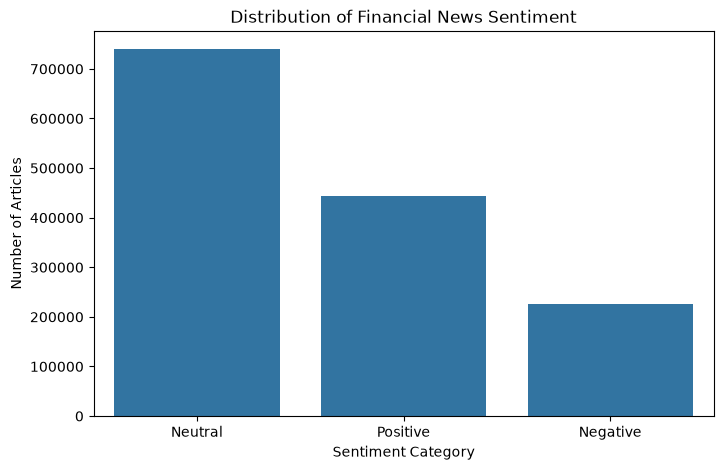

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=news,
    x="sentiment_category"
)

plt.title(
    "Distribution of Financial News Sentiment"
)

plt.xlabel("Sentiment Category")
plt.ylabel("Number of Articles")

plt.show()

In [22]:
stock_sentiment = (
    news
    .groupby("stock")["sentiment"]
    .mean()
    .sort_values()
)

stock_sentiment.head(10)

stock
GURX    -0.6696
SPPRO   -0.6249
VTWV    -0.5994
IDHQ    -0.5994
VGSH    -0.5994
VTHR    -0.5994
TROVW   -0.5267
SGYPU   -0.5267
SGYPW   -0.5267
WEET    -0.4824
Name: sentiment, dtype: float64

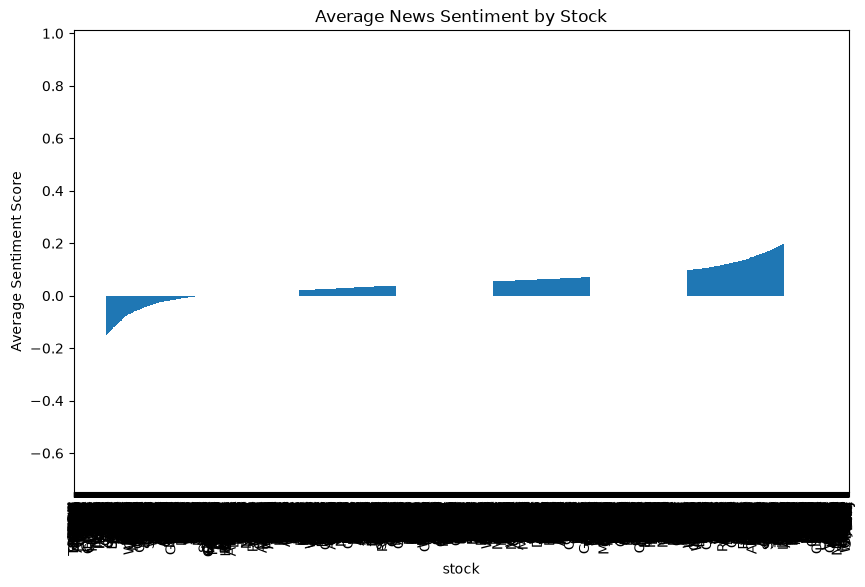

In [23]:
plt.figure(figsize=(10,6))

stock_sentiment.plot(
    kind="bar"
)

plt.title(
    "Average News Sentiment by Stock"
)

plt.ylabel(
    "Average Sentiment Score"
)

plt.show()

In [26]:
import os

os.getcwd()

'c:\\Users\\HP\\financial-news-stock-analysis\\notebooks'

In [27]:
import os

os.chdir(
    ".."
)

os.getcwd()

'c:\\Users\\HP\\financial-news-stock-analysis'

In [28]:
import pandas as pd

aapl = pd.read_csv(
    "data/raw/AAPL.csv"
)

aapl.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [29]:
aapl["Date"] = pd.to_datetime(aapl["Date"])

aapl.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [30]:
aapl["Daily_Return"] = (
    aapl["Close"].pct_change()
) * 100

aapl.head()

,Date,Close,High,Low,Open,Volume,Daily_Return
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,NaN
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,4.220416
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,-1.649399
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,-2.160860
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,1.856959


In [31]:
news["date"] = pd.to_datetime(news["date"])

news["Date"] = (
    news["date"]
    .dt.tz_localize(None)
    .dt.date
)

news.head()

,Unnamed: 0,headline,url,publisher,date,stock,headline_length,word_count,sentiment,sentiment_category,Date
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A,39,7,0.000,Neutral,2020-06-05
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A,42,7,0.000,Neutral,2020-06-03
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A,29,5,0.000,Neutral,2020-05-26
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A,44,7,0.000,Neutral,2020-05-22
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A,87,14,0.296,Positive,2020-05-22


In [32]:
aapl["Date"] = aapl["Date"].dt.date

aapl.head()

,Date,Close,High,Low,Open,Volume,Daily_Return
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,NaN
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,4.220416
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,-1.649399
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,-2.160860
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,1.856959


In [33]:
apple_news = news[
    news["stock"] == "AAPL"
]

apple_news.head()

,Unnamed: 0,headline,url,publisher,date,stock,headline_length,word_count,sentiment,sentiment_category,Date
6680,7120,Tech Stocks And FAANGS Strong Again To Start D...,https://www.benzinga.com/government/20/06/1622...,JJ Kinahan,2020-06-10 15:33:26+00:00,AAPL,69,13,0.5574,Positive,2020-06-10
6681,7121,10 Biggest Price Target Changes For Wednesday,https://www.benzinga.com/analyst-ratings/price...,Lisa Levin,2020-06-10 12:14:08+00:00,AAPL,45,7,0.0000,Neutral,2020-06-10
6682,7122,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",https://www.benzinga.com/short-sellers/20/06/1...,Benzinga Newsdesk,2020-06-10 11:53:47+00:00,AAPL,87,17,0.2023,Positive,2020-06-10
6683,7123,"Deutsche Bank Maintains Buy on Apple, Raises P...",https://www.benzinga.com/news/20/06/16219873/d...,Benzinga Newsdesk,2020-06-10 11:19:25+00:00,AAPL,65,11,0.0000,Neutral,2020-06-10
6684,7124,Apple To Let Users Trade In Their Mac Computer...,https://www.benzinga.com/news/20/06/16218697/a...,Neer Varshney,2020-06-10 10:27:11+00:00,AAPL,87,16,0.3818,Positive,2020-06-10


In [34]:
apple_news.shape

(441, 11)

In [35]:
daily_sentiment = (
    apple_news
    .groupby("Date")["sentiment"]
    .mean()
    .reset_index()
)

daily_sentiment.head()

,Date,sentiment
0,2020-03-09,-0.302067
1,2020-03-10,-0.090787
2,2020-03-11,-0.023850
3,2020-03-12,-0.207240
4,2020-03-13,-0.023191


In [36]:
merged = pd.merge(
    aapl,
    daily_sentiment,
    on="Date",
    how="inner"
)

merged.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,sentiment
0,2020-03-09,64.373756,67.256628,63.607082,63.788471,286744800,-7.909217,-0.302067
1,2020-03-10,69.010056,69.276094,65.147678,67.026873,285290000,7.202157,-0.090787
2,2020-03-11,66.613319,68.013645,65.749906,67.087355,255598800,-3.473025,-0.023850
3,2020-03-12,60.034924,65.300043,59.979299,61.899604,418474000,-9.875496,-0.207240
4,2020-03-13,67.227592,67.699207,61.176455,64.064172,370732000,11.980808,-0.023191


In [37]:
merged.shape

(61, 8)

In [38]:
correlation = merged[
    ["sentiment", "Daily_Return"]
].corr()

correlation

,sentiment,Daily_Return
sentiment,1.000000,0.123939
Daily_Return,0.123939,1.000000


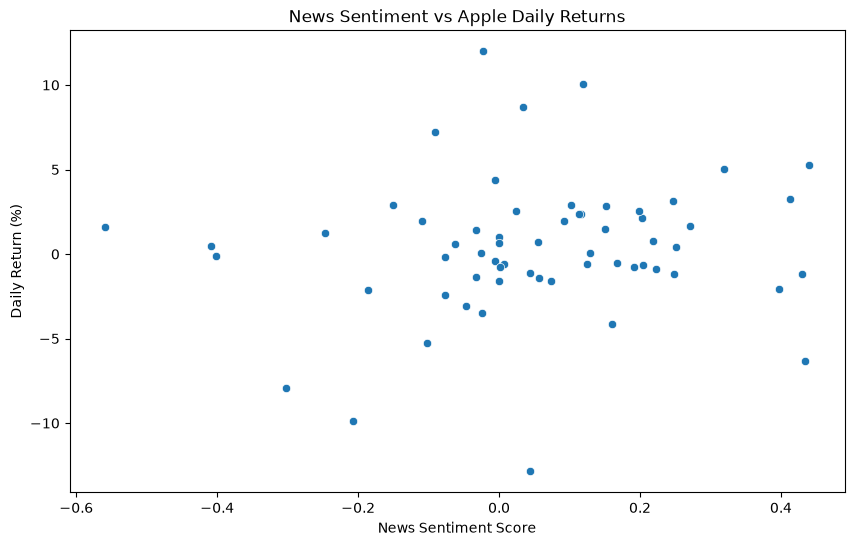

In [39]:
plt.figure(figsize=(10,6))


sns.scatterplot(
    data=merged,
    x="sentiment",
    y="Daily_Return"
)


plt.title(
    "News Sentiment vs Apple Daily Returns"
)

plt.xlabel(
    "News Sentiment Score"
)

plt.ylabel(
    "Daily Return (%)"
)

plt.show()

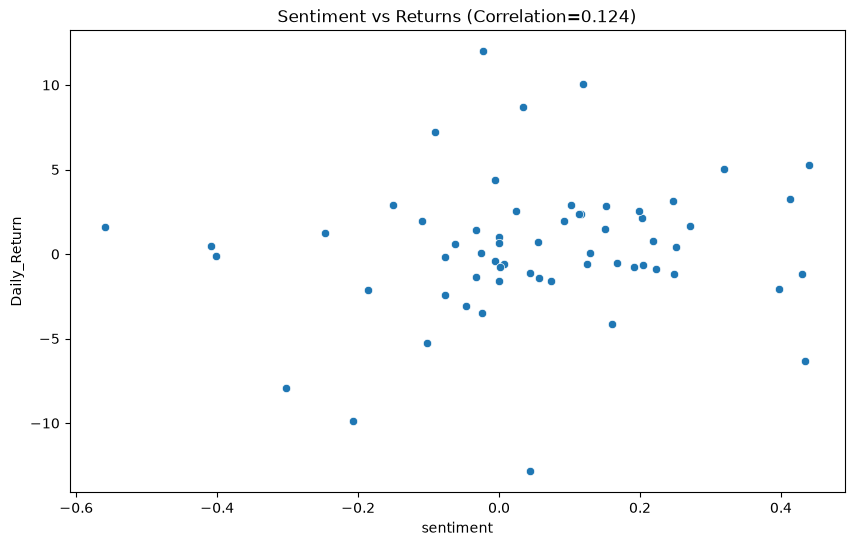

In [40]:
corr_value = merged[
    ["sentiment","Daily_Return"]
].corr().iloc[0,1]


plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged,
    x="sentiment",
    y="Daily_Return"
)


plt.title(
    f"Sentiment vs Returns (Correlation={corr_value:.3f})"
)


plt.show()

In [41]:
merged["sentiment_category"] = pd.cut(
    merged["sentiment"],
    bins=[-1,-0.05,0.05,1],
    labels=[
        "Negative",
        "Neutral",
        "Positive"
    ]
)

merged.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,sentiment,sentiment_category
0,2020-03-09,64.373756,67.256628,63.607082,63.788471,286744800,-7.909217,-0.302067,Negative
1,2020-03-10,69.010056,69.276094,65.147678,67.026873,285290000,7.202157,-0.090787,Negative
2,2020-03-11,66.613319,68.013645,65.749906,67.087355,255598800,-3.473025,-0.023850,Neutral
3,2020-03-12,60.034924,65.300043,59.979299,61.899604,418474000,-9.875496,-0.207240,Negative
4,2020-03-13,67.227592,67.699207,61.176455,64.064172,370732000,11.980808,-0.023191,Neutral


In [42]:
category_return = (
    merged
    .groupby(
        "sentiment_category",
        observed=True
    )["Daily_Return"]
    .mean()
)


category_return

sentiment_category
Negative   -0.856267
Neutral     0.324812
Positive    0.920500
Name: Daily_Return, dtype: float64

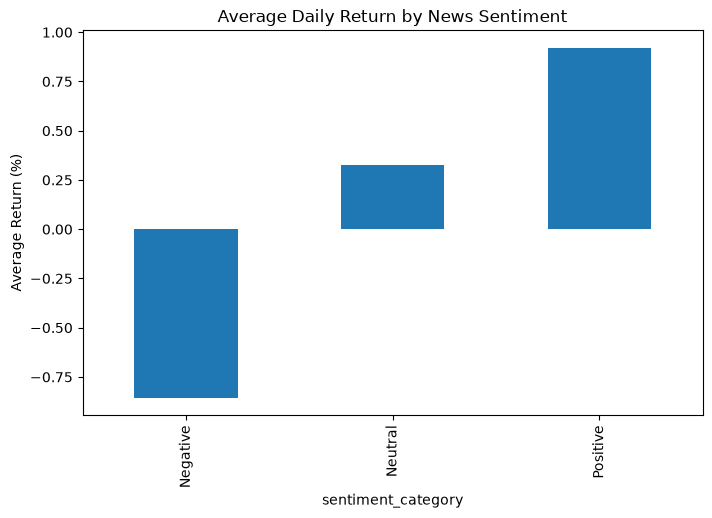

In [43]:
category_return.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Average Daily Return by News Sentiment"
)

plt.ylabel(
    "Average Return (%)"
)

plt.show()

In [46]:
correlation = merged["sentiment"].corr(
    merged["Daily_Return"]
)

print(
    f"Pearson correlation between sentiment and AAPL returns: {correlation:.3f}"
)

Pearson correlation between sentiment and AAPL returns: 0.124


In [47]:
category_return = (
    merged.groupby("sentiment_category")["Daily_Return"]
    .mean()
)


category_return

sentiment_category
Negative   -0.856267
Neutral     0.324812
Positive    0.920500
Name: Daily_Return, dtype: float64

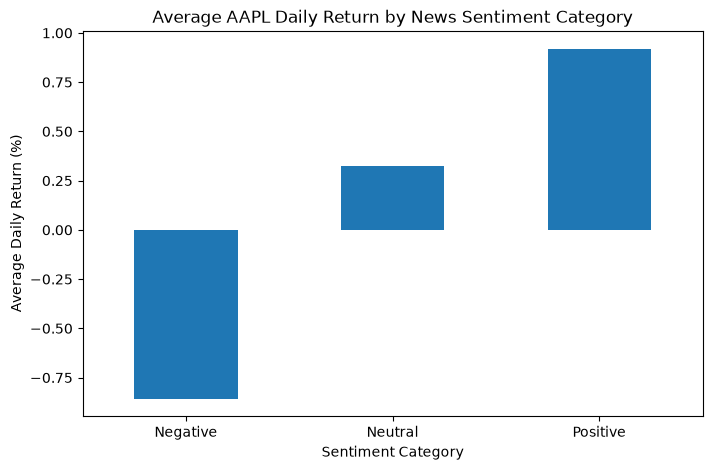

In [48]:
plt.figure(figsize=(8,5))

category_return.plot(
    kind="bar"
)

plt.title(
    "Average AAPL Daily Return by News Sentiment Category"
)

plt.xlabel("Sentiment Category")

plt.ylabel(
    "Average Daily Return (%)"
)

plt.xticks(rotation=0)

plt.show()

In [50]:
aapl.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return'], dtype='str')

In [51]:
aapl["SMA_20"] = (
    aapl["Close"]
    .rolling(window=20)
    .mean()
)


aapl["SMA_50"] = (
    aapl["Close"]
    .rolling(window=50)
    .mean()
)


aapl.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,SMA_20,SMA_50
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,NaN,NaN,NaN
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,4.220416,NaN,NaN
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,-1.649399,NaN,NaN
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,-2.160860,NaN,NaN
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,1.856959,NaN,NaN


In [52]:
final = merged.merge(
    aapl[["Date","SMA_20","SMA_50"]],
    on="Date",
    how="left"
)

final.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,sentiment,sentiment_category,SMA_20,SMA_50
0,2020-03-09,64.373756,67.256628,63.607082,63.788471,286744800,-7.909217,-0.302067,Negative,73.268222,74.233893
1,2020-03-10,69.010056,69.276094,65.147678,67.026873,285290000,7.202157,-0.090787,Negative,72.830349,74.215108
2,2020-03-11,66.613319,68.013645,65.749906,67.087355,255598800,-3.473025,-0.023850,Neutral,72.296099,74.148919
3,2020-03-12,60.034924,65.300043,59.979299,61.899604,418474000,-9.875496,-0.207240,Negative,71.341146,73.942862
4,2020-03-13,67.227592,67.699207,61.176455,64.064172,370732000,11.980808,-0.023191,Neutral,70.774002,73.870380


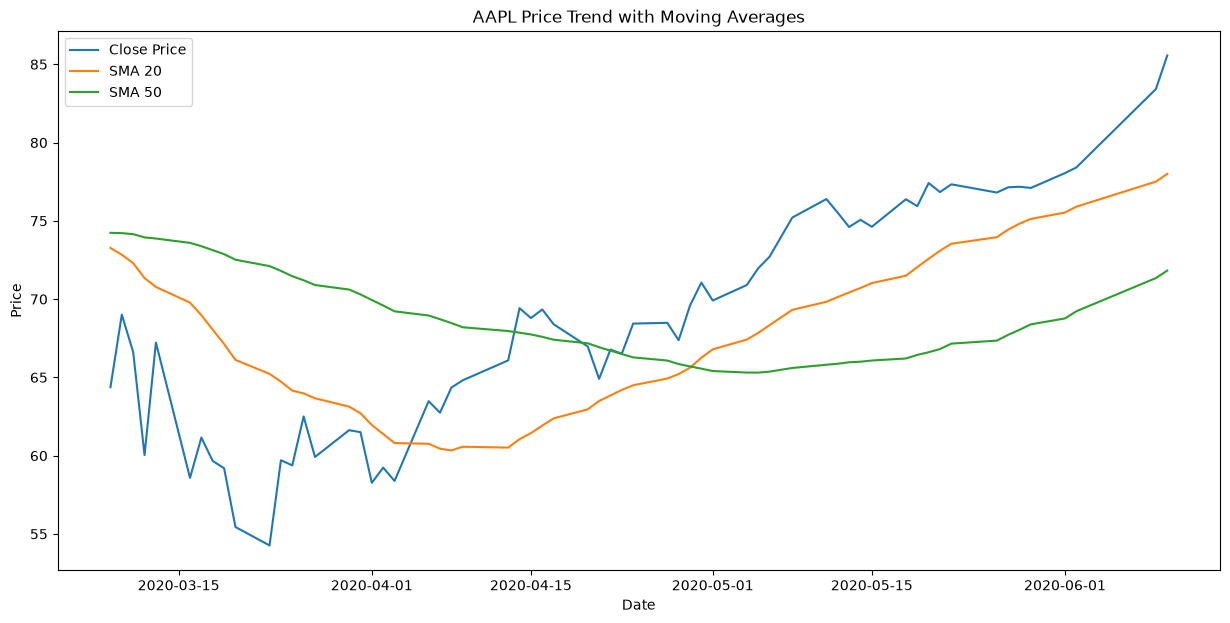

In [53]:
plt.figure(figsize=(15,7))


plt.plot(
    final["Date"],
    final["Close"],
    label="Close Price"
)


plt.plot(
    final["Date"],
    final["SMA_20"],
    label="SMA 20"
)


plt.plot(
    final["Date"],
    final["SMA_50"],
    label="SMA 50"
)


plt.title(
    "AAPL Price Trend with Moving Averages"
)

plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()

In [54]:
avg_return_category = (
    merged.groupby("sentiment_category")["Daily_Return"]
    .mean()
)

avg_return_category

sentiment_category
Negative   -0.856267
Neutral     0.324812
Positive    0.920500
Name: Daily_Return, dtype: float64

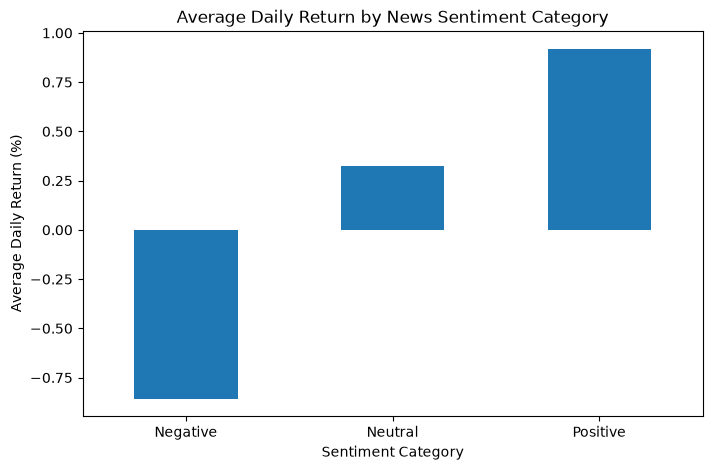

In [55]:
plt.figure(figsize=(8,5))

avg_return_category.plot(
    kind="bar"
)

plt.title(
    "Average Daily Return by News Sentiment Category"
)

plt.xlabel("Sentiment Category")
plt.ylabel("Average Daily Return (%)")

plt.xticks(rotation=0)

plt.show()

KeyError: 'SMA_20'

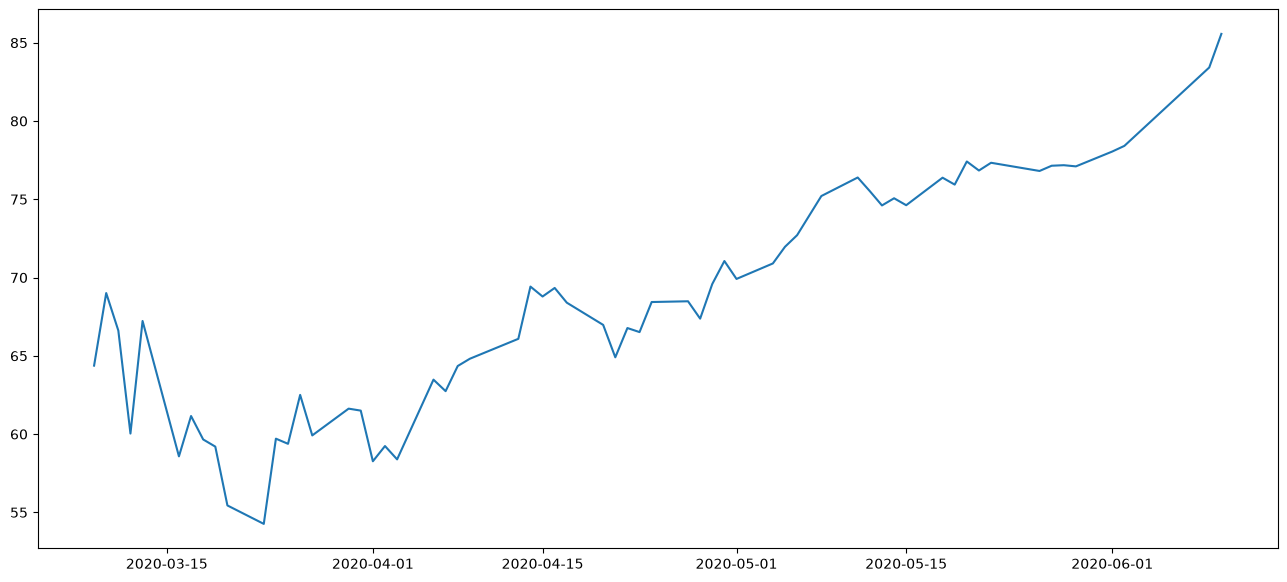

In [56]:
plt.figure(figsize=(16,7))


plt.plot(
    merged["Date"],
    merged["Close"],
    label="AAPL Close Price"
)


plt.plot(
    merged["Date"],
    merged["SMA_20"],
    label="SMA 20"
)


plt.plot(
    merged["Date"],
    merged["SMA_50"],
    label="SMA 50"
)


plt.title(
    "AAPL Price Trend with Moving Averages and News Analysis"
)

plt.xlabel("Date")
plt.ylabel("Price")


plt.legend()

plt.show()

In [57]:
merged.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return',
       'sentiment', 'sentiment_category'],
      dtype='str')

In [58]:
final = merged.merge(
    aapl[["Date","SMA_20","SMA_50"]],
    on="Date",
    how="left"
)

final.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,sentiment,sentiment_category,SMA_20,SMA_50
0,2020-03-09,64.373756,67.256628,63.607082,63.788471,286744800,-7.909217,-0.302067,Negative,73.268222,74.233893
1,2020-03-10,69.010056,69.276094,65.147678,67.026873,285290000,7.202157,-0.090787,Negative,72.830349,74.215108
2,2020-03-11,66.613319,68.013645,65.749906,67.087355,255598800,-3.473025,-0.023850,Neutral,72.296099,74.148919
3,2020-03-12,60.034924,65.300043,59.979299,61.899604,418474000,-9.875496,-0.207240,Negative,71.341146,73.942862
4,2020-03-13,67.227592,67.699207,61.176455,64.064172,370732000,11.980808,-0.023191,Neutral,70.774002,73.870380


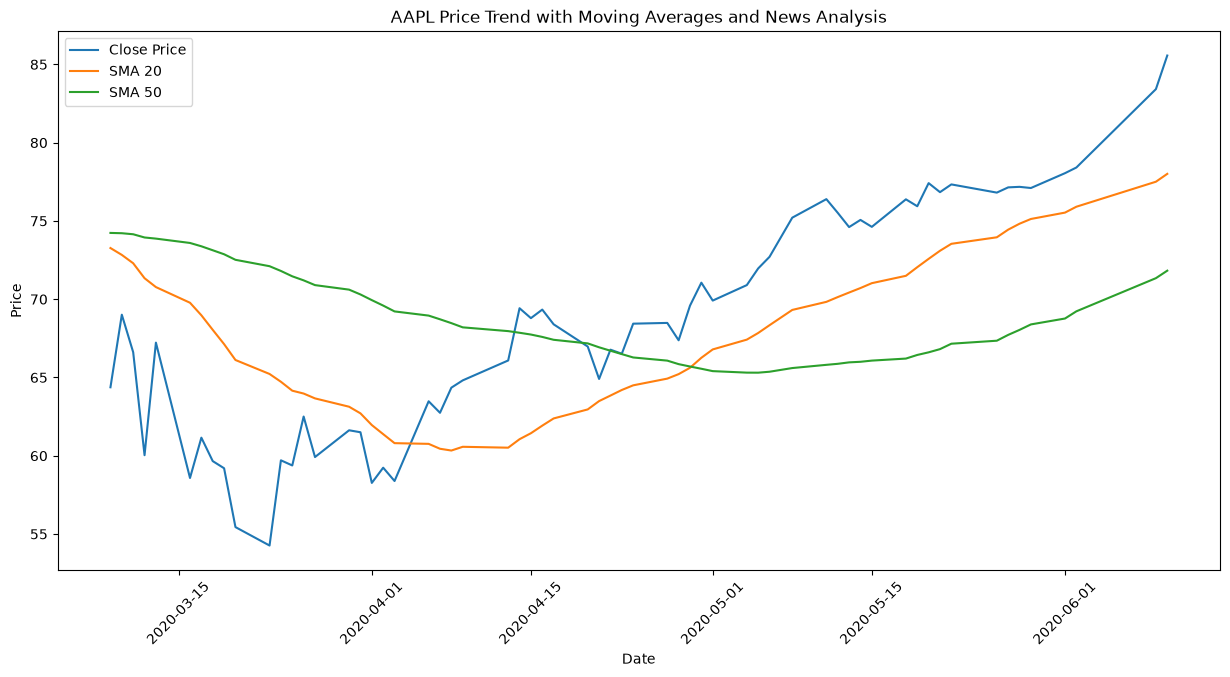

In [59]:
plt.figure(figsize=(15,7))


plt.plot(
    final["Date"],
    final["Close"],
    label="Close Price"
)


plt.plot(
    final["Date"],
    final["SMA_20"],
    label="SMA 20"
)


plt.plot(
    final["Date"],
    final["SMA_50"],
    label="SMA 50"
)


plt.title(
    "AAPL Price Trend with Moving Averages and News Analysis"
)

plt.xlabel("Date")
plt.ylabel("Price")


plt.legend()

plt.xticks(rotation=45)

plt.show()

In [60]:
summary = final.groupby(
    "sentiment_category"
)["Daily_Return"].mean()

summary

sentiment_category
Negative   -0.856267
Neutral     0.324812
Positive    0.920500
Name: Daily_Return, dtype: float64

Positive news sentiment days produced higher average returns, while negative sentiment days showed negative average returns. This suggests that investor sentiment extracted from financial news has a measurable relationship with short-term stock movements.

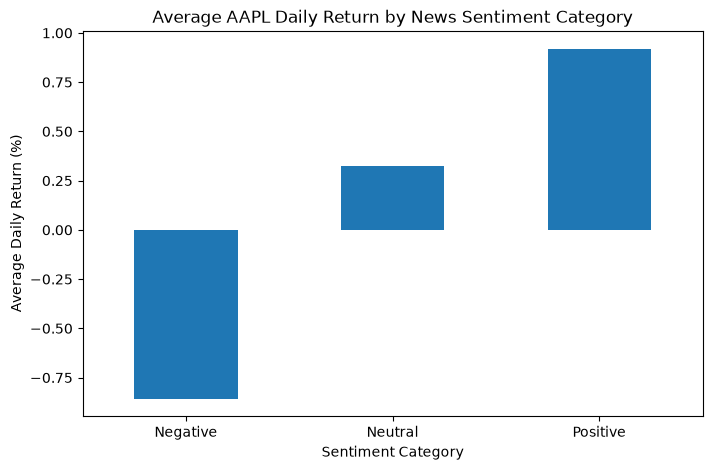

In [62]:
plt.figure(figsize=(8,5))


summary.plot(
    kind="bar"
)


plt.title(
    "Average AAPL Daily Return by News Sentiment Category"
)

plt.xlabel("Sentiment Category")
plt.ylabel("Average Daily Return (%)")


plt.xticks(rotation=0)

plt.show()